In [13]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from torch.linalg import eigvalsh
from tqdm import tqdm
import pandas as pd
import os
import copy
import matplotlib.pyplot as plt
from scipy.linalg import eigvals as scipy_eigvals

In [ ]:


num_iter = 15000

torch.backends.cudnn.enabled = False
dtype = torch.float64
torch.set_default_dtype(dtype)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device: ", device)

# Parameters

Nc = 3
g5_sq = (12*np.pi**2)/Nc

omega_a1 = torch.tensor([1.26, 1.64], device=device)  # in GeV
omega_a2 = torch.tensor([1.32, 1.70], device=device)  # in GeV
omega_rho = torch.tensor([0.77, 1.45, 1.57, 1.7, 1.9, 2.15], device=device)
omega_f0 = torch.tensor([0.5, 0.98, 1.37, 1.5, 1.7, 1.83, 2.0, 2.15, 2.3, 2.4, 2.55], device=device)  # in GeV
omega_pi = torch.tensor([0.134, 1.3, 1.8], device=device)  # in GeV

z_max = 10.0
h = 0.1
z_ini = h

def V_k_fn(v_z, k1, k2):
    return (k2)*v_z**3 + k1*v_z**2

fpi_sq = (92.4e-3)**2  # in GeV^2
mpi_sq = (139.57e-3)**2  # in GeV^2

zeta = np.sqrt(Nc)/(2*np.pi)

def Sigma_fn(theta, scale=1):
    return 0.01 + (0.03 - 0.01)*torch.sigmoid(theta*scale)

def ab_fn(theta, L):
    Sigma = Sigma_fn(theta)
    m_q = fpi_sq*mpi_sq/(2*Sigma)
    alpha = zeta*m_q*L
    beta = (Sigma/zeta)*(L**3)

    return alpha, beta

# DEFINE A(z) THE NEURAL NETWORK
n_neurons = [50, 50, 50, 50]

class A_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [-1, 1]
        #z = 2.0 * (z) / (z_max) - 1.0

        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()


# DEFINE v(z)THE NEURAL NETWORK
#n_neurons = [20, 20, 20, 20] # number of neurons in each hidden layer

class v_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()
    
def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        #torch.nn.init.xavier_normal_(m.weight)

def v_z_fn(z, model_v, theta, L):
    alpha, beta = ab_fn(theta, L)
    return (alpha*z + beta*z**3 + model_v(z)*z**4)/(1+z**3)

def A_z_fn(z, model_A):
    return -torch.log(z) + z*model_A(z)*0.1

def B2_dash_z_fn(exp_2A_z, v_z, dv_dz, d2v_dz2, k1, k2):
    return (d2v_dz2 - exp_2A_z*(-3*v_z - V_k_fn(v_z, k1, k2)))/dv_dz


def V_mesons(model_A, model_v,  k1, k2, theta, L, z=None):
    if z is None:
        z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]
    
    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2,  k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    d2B2_dz2 = autograd.grad(dB2_dz, z, torch.ones_like(dB2_dz), create_graph=True)[0]
    d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

    V_rho = 0.25*dB1_dz**2 - 0.5*d2B1_dz2
    V_a1 = V_rho + g5_sq*exp_2A*v_z**2
    V_a2 = 0.25*dB2_dz**2 - 0.5*d2B2_dz2
    V_f0 = V_a2 + exp_2A*(-3 - (2*k1*v_z + 3*(k2)*v_z**2)) 

    return V_rho, V_a1, V_a2, V_f0

def eigenvalues_square_fn(model_A, model_v,  k1, k2, theta, L, no_eigenvalues = (2, 2, 2, 2)):
    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L)
    diag_elem_rho = 2 + V_rho*h**2
    diag_elem_a1 = 2 + V_a1*h**2
    diag_elem_a2 = 2 + V_a2*h**2
    diag_elem_f0 = 2 + V_f0*h**2

    off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

    mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a1 = (torch.diag(diag_elem_a1) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a2 = (torch.diag(diag_elem_a2) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_f0 = (torch.diag(diag_elem_f0) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2

    eigenvalues_rho = eigvalsh(mat_rho)[:no_eigenvalues[0]]/(L**2)
    eigenvalues_a1 = eigvalsh(mat_a1)[:no_eigenvalues[1]]/(L**2)
    eigenvalues_a2 = eigvalsh(mat_a2)[:no_eigenvalues[2]]/(L**2)
    eigenvalues_f0 = eigvalsh(mat_f0)[:no_eigenvalues[3]]/(L**2)

    return eigenvalues_rho, eigenvalues_a1, eigenvalues_a2, eigenvalues_f0

################################################################################################################################
################################################ Loss Functions ################################################################
################################################################################################################################

# Mass loss
def mass_loss_fn(model_A, model_v,  k1, k2, theta, L):

    mbyL_rho, mbyL_a1, mbyL_a2, mbyL_f0 = eigenvalues_square_fn(model_A, model_v, k1, k2, theta, L, (len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0), len(omega_pi)))
    rho_mass_loss = torch.abs(mbyL_rho - omega_rho**2)/omega_rho**2
    a1_mass_loss = torch.abs(mbyL_a1 - omega_a1**2)/omega_a1**2
    a2_mass_loss = torch.abs(mbyL_a2 - omega_a2**2)/omega_a2**2
    f0_mass_loss = torch.abs(mbyL_f0 - omega_f0**2)/omega_f0**2

    sum_loss = (rho_mass_loss.sum() + a1_mass_loss.sum() + a2_mass_loss.sum() + f0_mass_loss.sum()).detach()

    rho_scaling = rho_mass_loss.detach()/sum_loss
    a1_scaling = a1_mass_loss.detach()/sum_loss
    a2_scaling = a2_mass_loss.detach()/sum_loss
    f0_scaling = f0_mass_loss.detach()/sum_loss

    rho_mass_loss = (rho_mass_loss * rho_scaling).mean()
    a1_mass_loss = (a1_mass_loss * a1_scaling).mean()
    a2_mass_loss = (a2_mass_loss * a2_scaling).mean()
    f0_mass_loss = (f0_mass_loss * f0_scaling).mean()

    return rho_mass_loss, a1_mass_loss, a2_mass_loss, f0_mass_loss

def pos_v_dash_loss_fn(model_v, theta, L):
    z = torch.rand(100, device=device, requires_grad=True)*z_max
    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    return nn.ReLU()(-dv_dz).sum()

def A_z_IR_loss_fn(model_A):
    z = torch.tensor([z_max], device=device, requires_grad=True)
    A_z = A_z_fn(z, model_A)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    return nn.ReLU()(A_z + torch.log(z)-1.5).sum() + nn.ReLU()(dA_dz).sum()

def pot_dash_IR_loss_fn(model_A, model_v, k1, k2, theta, L): # potential should be increasing at IR
    #z = torch.linspace(z_max*(0.8), z_max, 10, device=device, requires_grad=True)
    z = torch.rand(1, device=device, requires_grad=True)*(z_max*0.2) + z_max*0.8

    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v, k1, k2, theta, L, z)
    V_dash_rho = autograd.grad(V_rho, z, torch.ones_like(V_rho), create_graph=True)[0]
    V_dash_a2 = autograd.grad(V_a2, z, torch.ones_like(V_a2), create_graph=True)[0]
    return nn.ReLU()(-V_dash_rho).sum() + nn.ReLU()(-V_dash_a2).sum()



Using device:  cpu


In [15]:
k1 = nn.Parameter(torch.tensor(-7.4, device=device))
k2 = nn.Parameter(torch.tensor(12.2, device=device))

l = nn.Parameter(torch.tensor(1.0, device=device))

print("k initial: ", k1.item(), k2.item())

theta = nn.Parameter(torch.tensor(0.0, device=device))

# Instantiate the model
model_v = v_LinearNN().to(device)
model_A = A_LinearNN().to(device)

model_v.apply(weights_init)
model_A.apply(weights_init)

min_loss = torch.inf
min_de_loss = torch.inf

best_model_v = None
best_model_A = None
best_k1 = None
best_k2 = None
best_L = None
best_theta = None

mass_loss_arr = []
de_loss_arr = []
total_loss_arr = []

k initial:  -7.4 12.2


In [16]:
optimizer_net = torch.optim.Adam(list(model_A.parameters()) + list(model_v.parameters()), lr=5e-4)
optimizer_k = torch.optim.Adam([k1, k2, l, theta], lr=5e-2)

scheduler_net = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_net, mode='min', factor=0.95, patience=100, min_lr=1e-8)
scheduler_k = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_k, mode='min', factor=0.6, patience=200, min_lr=1e-5)

In [17]:
#pbar = tqdm(total=num_iter)
pbar = tqdm(range(num_iter))

try:
    for i in pbar:
        L = torch.log(1 + l**2)
        optimizer_net.zero_grad()
        optimizer_k.zero_grad()

        

        mass_loss = mass_loss_fn(model_A, model_v, k1, k2, theta, L)
        

        total_loss = 0
        total_loss += mass_loss[0]  # Rho mass loss
        total_loss += mass_loss[1]  # A1 mass loss
        total_loss += mass_loss[2]  # A2 mass loss
        total_loss += mass_loss[3]  # f0 mass loss
        
        total_loss += pos_v_dash_loss_fn(model_v, theta, L)*10
        total_loss += A_z_IR_loss_fn(model_A)
        total_loss += pot_dash_IR_loss_fn(model_A, model_v, k1, k2, theta, L)

        total_loss_arr.append(total_loss.item())
        mass_loss_arr.append([loss.item() for loss in mass_loss])

        total_loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model_A.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model_v.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_([k2, l, theta], max_norm=1.0)

        optimizer_net.step()
        optimizer_k.step()

        scheduler_net.step(total_loss.item())
        scheduler_k.step(total_loss.item())

        pbar.set_description(f"Loss: {total_loss.item():.5f}, Min Loss: {min_loss:.5f}")
        pbar.postfix = { 
            'lr': f"[{scheduler_net.get_last_lr()[0]:.1e}, {scheduler_k.get_last_lr()[0]:.1e}]",
            'L': f"{L.item():.2f}",

            'k': f"[{k1.item():.2f}, {k2.item():.2f}]",

            'theta': f"{theta.item():.2f}",

            'Sigma': f"({Sigma_fn(theta)**(1/3):.5f} GeV)^3",
        }

        # check for nan loss
        if torch.isnan(total_loss):
            raise RuntimeError("Training Failed !!! NaN loss encountered.")
        
        if total_loss.item() < min_loss:
            min_loss = total_loss.item()
            best_model_v = copy.deepcopy(model_v)
            best_model_A = copy.deepcopy(model_A)
            best_k1 = copy.deepcopy(k1)
            best_k2 = copy.deepcopy(k2)
            best_L = copy.deepcopy(L.item())
            best_theta = copy.deepcopy(theta)

        """ if i == 1000 and min_loss > 1:
            raise RuntimeError("Training Failed !!! Loss did not decrease.")
        if i == 5000 and min_loss > 0.5:
            raise RuntimeError("Training Failed !!! Loss did not decrease.")
        
        if scheduler_net.get_last_lr()[0] < 2e-8:
            print("Learning saturated. Ending training.")
            break """

except KeyboardInterrupt:
    print("Training interrupted.")

pbar.close()

####################################################################################################################
################################################### Training Complete ##############################################
####################################################################################################################

Loss: 0.01041, Min Loss: 0.01006: 100%|██████████| 15000/15000 [24:24<00:00, 10.24it/s{'lr': '[5.5e-06, 1.0e-05]', 'L': '1.45', 'k': '[-7.14, 15.32]', 'theta': '0.29', 'Sigma': '(0.27772 GeV)^3'}]


In [18]:
print("Best Loss: ", min_loss)
eigval_rho, eigval_a1, eigval_a2, eigval_f0 = eigenvalues_square_fn(best_model_A, best_model_v, best_k1, best_k2, best_theta, best_L, (len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0), len(omega_pi)))

print("DE Loss at Best Model: ", min_de_loss)

print("\nBest k1: ", best_k1.item())
print("Best k2: ", best_k2.item())
print("Best L: ", best_L)
print("Best theta: ", best_theta.item())

mass_rho = torch.sqrt(eigval_rho)
mass_a1 = torch.sqrt(eigval_a1)
mass_a2 = torch.sqrt(eigval_a2)
mass_f0 = torch.sqrt(eigval_f0)

mass_loss_np = np.array(mass_loss_arr)

Best Loss:  0.01006020025261004
DE Loss at Best Model:  inf

Best k1:  -7.1353345670557164
Best k2:  15.319260481211973
Best L:  1.4526807929005439
Best theta:  0.2903970478971721


In [19]:

if (eigval_rho < 0).any() or (eigval_a1 < 0).any() or (eigval_a2 < 0).any() or (eigval_f0 < 0).any():
    #raise RuntimeError("Training Failed !!! Negative eigenvalue found.")
    print("Training Failed !!! Negative eigenvalue found.")
elif min_loss > 0.01:
    #raise RuntimeError("Training Failed !!!")
    print("Training Failed !!! Final Total Loss too high.")
else:
    print("Training Successful !!!")
    print("Saving Model and Parameters...")
    if not os.path.exists('saved'):
        os.makedirs('saved')
    # get all directories in saved folder

    saved_dirs = [d for d in os.listdir('saved') if os.path.isdir(os.path.join('saved', d))]
    new_folder_name = str(len(saved_dirs))
    os.makedirs(f'saved/{new_folder_name}')

    # save the model, k1, k2, theta and losses to a file
    torch.save(best_model_A.state_dict(), 'saved/' + new_folder_name + '/model_A.pth')
    torch.save(best_model_v.state_dict(), 'saved/' + new_folder_name + '/model_v.pth')

    with open('saved/' + new_folder_name + '/params.txt', 'w') as f:
        f.write(f'min_loss: {min_loss}\n')
        f.write(f'k1: {best_k1.item()}\n')
        f.write(f'k2: {best_k2.item()}\n')
        f.write(f'theta: {best_theta.item()}\n')
        f.write(f'L: {best_L}\n')

    # save mass loss to a csv file
    mass_loss_df = pd.DataFrame(mass_loss_np, columns=['rho_mass_loss', 'a1_mass_loss', 'a2_mass_loss', 'f0_mass_loss'])
    mass_loss_df.to_csv('saved/' + new_folder_name + '/mass_loss.csv', index=False)




Training Failed !!! Final Total Loss too high.


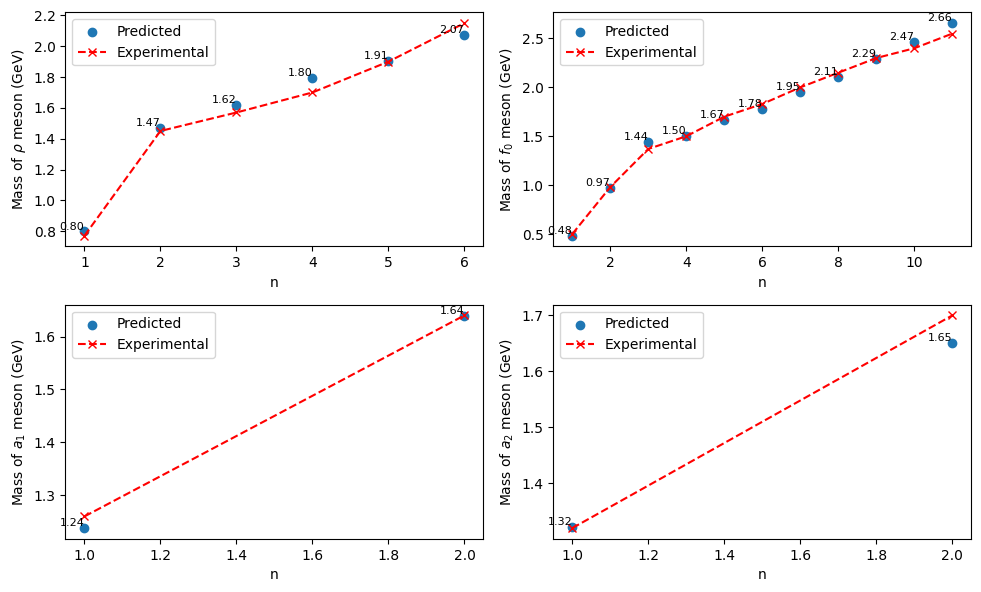

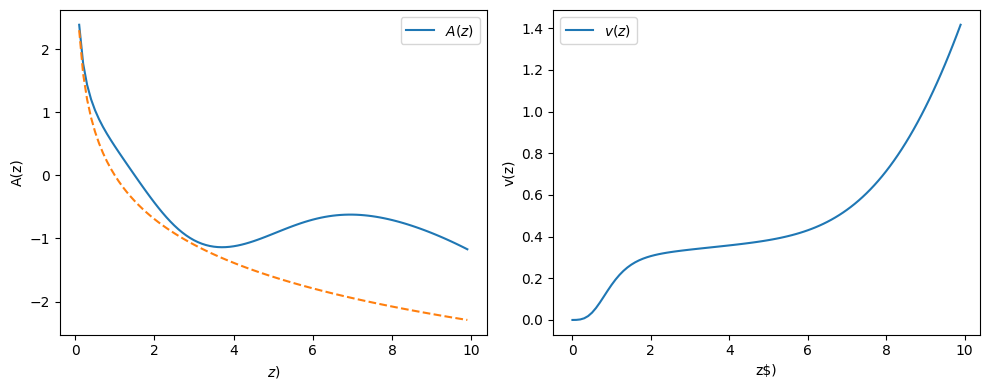

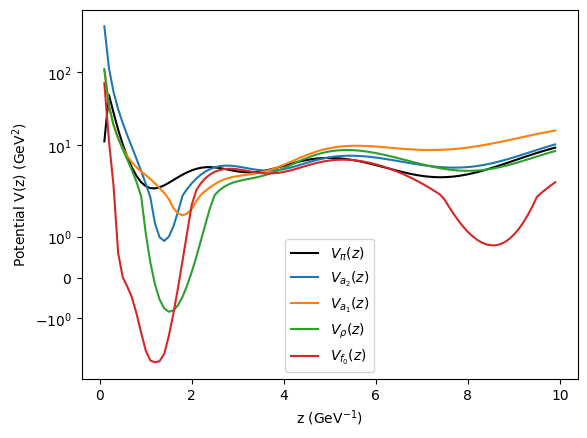

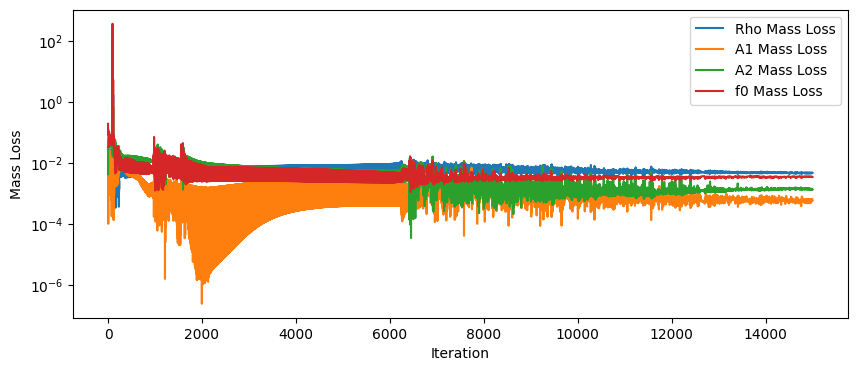

In [20]:

# Plot predicted vs experimental masses
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = axs.flatten()

axs[0].scatter(range(1, len(mass_rho)+1), mass_rho.cpu().detach().numpy(), label='Predicted')
axs[0].plot(range(1, len(omega_rho)+1), omega_rho.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(omega_rho)):
    axs[0].text(i+1, mass_rho[i].item(), f"{mass_rho[i].item():.2f}", color='black', ha='right', va='bottom', fontsize=8)
axs[0].set_xlabel("n")
axs[0].set_ylabel("Mass of $\\rho$ meson (GeV)")
axs[0].legend()

axs[1].scatter(range(1, len(mass_f0)+1), mass_f0.cpu().detach().numpy(), label='Predicted')
axs[1].plot(range(1, len(omega_f0)+1), omega_f0.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(omega_f0)):
    axs[1].text(i+1, mass_f0[i].item(), f"{mass_f0[i].item():.2f}", color='black', ha='right', va='bottom', fontsize=8)
axs[1].set_xlabel("n")
axs[1].set_ylabel("Mass of $f_0$ meson (GeV)")
axs[1].legend()

axs[2].scatter(range(1, len(mass_a1)+1),mass_a1.cpu().detach().numpy(), label='Predicted')
axs[2].plot(range(1, len(omega_a1)+1), omega_a1.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(omega_a1)):
    axs[2].text(i+1, mass_a1[i].item(), f"{mass_a1[i].item():.2f}", color='black', ha='right', va='bottom', fontsize=8)
axs[2].set_xlabel("n")
axs[2].set_ylabel("Mass of $a_1$ meson (GeV)")
axs[2].legend()

axs[3].scatter(range(1, len(mass_a2)+1),mass_a2.cpu().detach().numpy(), label='Predicted')
axs[3].plot(range(1, len(omega_a2)+1), omega_a2.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(omega_a2)):
    axs[3].text(i+1, mass_a2[i].item(), f"{mass_a2[i].item():.2f}", color='black', ha='right', va='bottom', fontsize=8)
axs[3].set_xlabel("n")
axs[3].set_ylabel("Mass of $a_2$ meson (GeV)")
axs[3].legend()

plt.tight_layout()
#plt.savefig('saved/' + new_folder_name + '/mass_plot.jpg')
#plt.clf()
plt.show()

# plot A(z) and v(z)

z = torch.arange(0, z_max, h, device=device, requires_grad=True)
A_z = A_z_fn(z, best_model_A)
v_z = v_z_fn(z, best_model_v, theta, L)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(z.cpu().detach().numpy(), A_z.cpu().detach().numpy())
axs[0].plot(z.cpu().detach().numpy(), -torch.log(z).cpu().detach().numpy(), linestyle='dashed')
axs[0].set_xlabel("$z$)")
axs[0].set_ylabel("A(z)")
axs[0].legend(["$A(z)$"])

axs[1].plot(z.cpu().detach().numpy(), v_z.cpu().detach().numpy())
axs[1].set_xlabel("z$)")
axs[1].set_ylabel("v(z)")
axs[1].legend(["$v(z)$"])
#axs[1].set_yscale('symlog')
plt.tight_layout()
#plt.savefig('saved/' + new_folder_name + '/A_v_plot.jpg')
#plt.clf()
plt.show()

# plot potentials
dz = 0.1
z_for_pi = torch.arange(dz, z_max, dz, device=device, requires_grad=True)
A_z = A_z_fn(z_for_pi, best_model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z_for_pi, torch.ones_like(A_z), create_graph=True)[0]
d2A_dz2 = autograd.grad(dA_dz, z_for_pi, torch.ones_like(dA_dz), create_graph=True)[0]

v_z = v_z_fn(z_for_pi, best_model_v, best_theta, best_L)
dv_dz = autograd.grad(v_z, z_for_pi, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z_for_pi, torch.ones_like(dv_dz), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, best_k1, best_k2)
dB1_dz = dB2_dz + 2*dA_dz

d2B2_dz2 = autograd.grad(dB2_dz, z_for_pi, torch.ones_like(dB2_dz), create_graph=True)[0]
d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

omega = 2*dv_dz/v_z - dB2_dz

V_rho = 0.25*dB1_dz**2 - 0.5*d2B1_dz2
V_a1 = V_rho + g5_sq*exp_2A*v_z**2
V_a2 = 0.25*dB2_dz**2 - 0.5*d2B2_dz2
V_f0 = V_a2 + exp_2A*(-3 - (2*k1*v_z + 3*(k2)*v_z**2))

V_pi = 0.25*dB2_dz**2 + 0.5*d2B2_dz2  - (d2v_dz2/v_z) + (dv_dz/v_z)*omega

plt.plot(z_for_pi.cpu().detach().numpy(), V_pi.cpu().detach().numpy(), label='$V_{\\pi}(z)$', color='black')
plt.plot(z_for_pi.cpu().detach().numpy(), V_a2.cpu().detach().numpy(), label='$V_{a_2}(z)$')
plt.plot(z_for_pi.cpu().detach().numpy(), V_a1.cpu().detach().numpy(), label='$V_{a_1}(z)$')
plt.plot(z_for_pi.cpu().detach().numpy(), V_rho.cpu().detach().numpy(), label='$V_\\rho(z)$')
plt.plot(z_for_pi.cpu().detach().numpy(), V_f0.cpu().detach().numpy(), label='$V_{f_0}(z)$')

plt.xlabel("z (GeV$^{-1}$)")
plt.ylabel("Potential V(z) (GeV$^2$)")
plt.legend()
plt.yscale('symlog')
#plt.savefig('saved/' + new_folder_name + '/potential_plot.jpg')
#plt.clf()
plt.show()

# Plot losses
plt.figure(figsize=(10, 4))
plt.plot(mass_loss_np[:,0], label='Rho Mass Loss')
plt.plot(mass_loss_np[:,1], label='A1 Mass Loss')
plt.plot(mass_loss_np[:,2], label='A2 Mass Loss')
plt.plot(mass_loss_np[:,3], label='f0 Mass Loss')
#axs[0].plot(total_loss_arr, label='Total Loss', color='black')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Mass Loss')
plt.legend()

#plt.savefig('saved/' + new_folder_name + '/loss_plot.jpg')
#plt.clf()
plt.show()

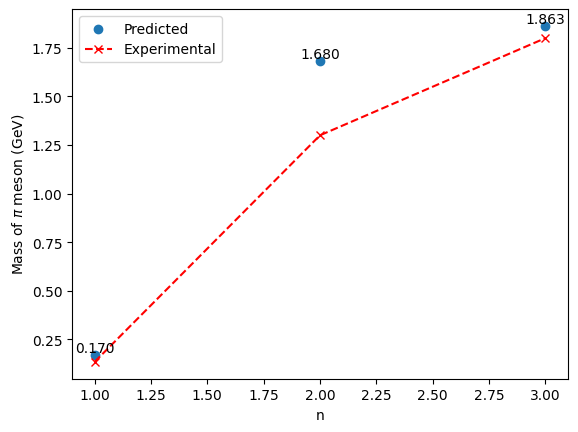

In [21]:
dz = 0.1
z = torch.arange(dz, z_max, dz, requires_grad=True, device=device)

v_z = v_z_fn(z, best_model_v, best_theta, best_L)
dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

A_z = A_z_fn(z, best_model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, best_k1, best_k2)
dB1_dz = dB2_dz + 2*dA_dz

omega_z = 2*dv_dz/v_z - dB2_dz
C_z = g5_sq*exp_2A*v_z**2

# making M1 matrix
diag_elem_M1 = -2/dz**2 * torch.ones_like(z)
off_diag_elem_M1_plus = 1/dz**2 + omega_z[:-1]/(2*dz)
off_diag_elem_M1_minus = 1/dz**2 - omega_z[1:]/(2*dz)
M1 = torch.diag(diag_elem_M1) + torch.diag(off_diag_elem_M1_plus, diagonal=1) + torch.diag(off_diag_elem_M1_minus, diagonal=-1)

# making M2 matrix
M2 = torch.diag(C_z)

# making M3 matrix
diag_elem_M3 = -2/dz**2 - C_z
off_diag_elem_M3_plus = 1/dz**2 - dB1_dz[:-1]/(2*dz)
off_diag_elem_M3_minus = 1/dz**2 + dB1_dz[1:]/(2*dz)
M3 = torch.diag(diag_elem_M3) + torch.diag(off_diag_elem_M3_plus, diagonal=1) + torch.diag(off_diag_elem_M3_minus, diagonal=-1)

M = torch.zeros((2*len(z), 2*len(z)), device=device)
M[:len(z), :len(z)] = M1
M[len(z):, :len(z)] = M2
M[len(z):, len(z):] = M3

# make T = [[-1, 1], [0, 0]]
T = torch.zeros((2*len(z), 2*len(z)), device=device)
T[:len(z), :len(z)] = -1*torch.eye(len(z))
T[:len(z), len(z):] = torch.eye(len(z))

M = M.cpu().detach().numpy()
T = T.cpu().detach().numpy()

# solve generalized eigenvalue problem using scipy
eigenvalues_pi = scipy_eigvals(M, T)
# sort eigenvalues
eigenvalues_pi = np.sort(eigenvalues_pi.real)
eigenvalues_pi = eigenvalues_pi[:len(omega_pi)]/(best_L**2)
pi_mass = np.sqrt(eigenvalues_pi)

plt.scatter(range(1, len(pi_mass)+1), pi_mass, label='Predicted')
plt.plot(range(1, len(omega_pi)+1), omega_pi.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(pi_mass)):
    plt.text(i+1, pi_mass[i].item(), f"{pi_mass[i].item():.3f}", ha='center', va='bottom')
plt.xlabel("n")
plt.ylabel("Mass of $\\pi$ meson (GeV)")
plt.legend()
plt.show()
